In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings 
import logging
import seaborn as sns

working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs



# --- add this near the top (after imports) ---
COND_ORDER = [
    "Control",
    "Standard protocol",
    "Extended protocol",
    "Prematurely terminated",
    "PCMV",
    "Rejection",
]

COND_PALETTE = {
    "Control": "#EFE48E",
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
    "Prematurely terminated": "#C9B8D9",
    "PCMV": "#F0C096",
    "Rejection": "#E09E9E",
}


Running Scanpy 1.11.3, on 2025-10-22 09:53.


In [2]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/merging UMIs/CC_prepared_global_adata_raw_WITHOUT_lognorm.h5ad')

In [3]:
global_adata

AnnData object with n_obs × n_vars = 186947 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors'
    obsm: 'X_pca', 'X_umap'

Subsetted AnnData object for CM: AnnData object with n_obs × n_vars = 137794 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors'
    obsm: 'X_pca', 'X_umap'

DataFrame of Cell State Compositions:
           

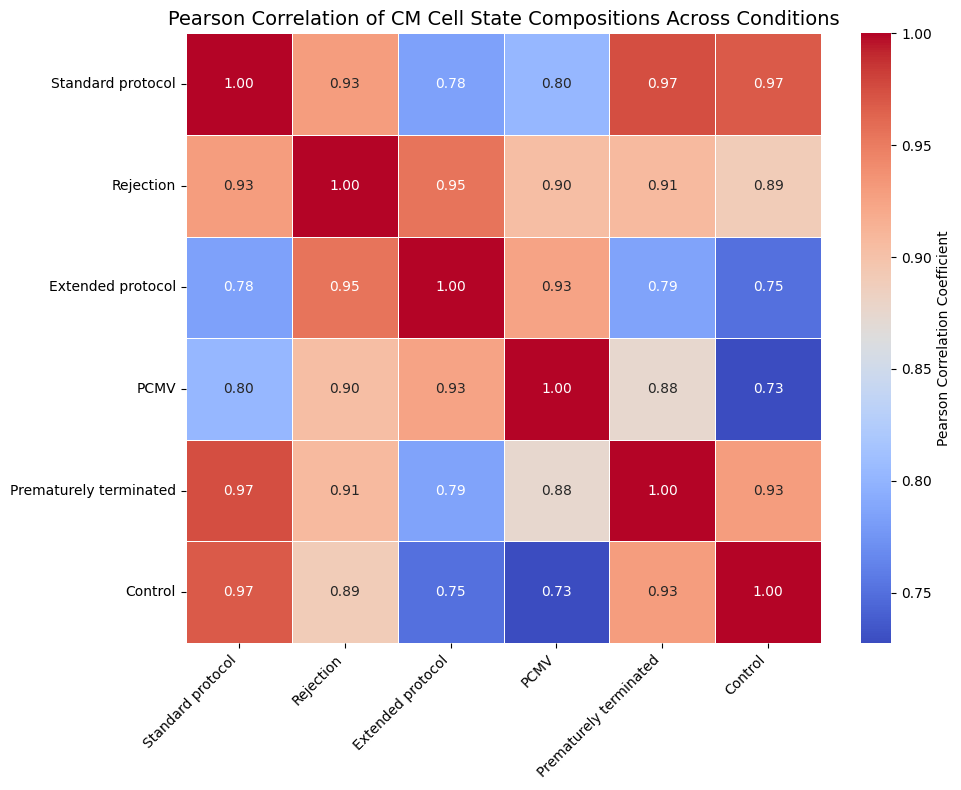

Heatmap of Pearson correlation for CM cell state compositions has been generated.


In [4]:
# --- Subsetting the AnnData object ---
cm_adata = global_adata[global_adata.obs['cell_type'] == 'CM', :].copy()
print(f"Subsetted AnnData object for CM: {cm_adata}")

# --- Calculate Cell State Compositions ---
# Create an empty dictionary to store cell state counts for each condition
composition_data = {}

# Get the unique conditions and cell states
conditions = cm_adata.obs['Condition_subsets'].unique()
cell_states = cm_adata.obs['cell_states'].unique()

# Iterate through each condition and count the occurrences of each cell state
for cond in conditions:
    cond_adata = cm_adata[cm_adata.obs['Condition_subsets'] == cond]
    state_counts = cond_adata.obs['cell_states'].value_counts()
    # Normalize the counts to get proportions
    state_proportions = state_counts / len(cond_adata)
    composition_data[cond] = state_proportions.reindex(cell_states, fill_value=0)

# Convert the dictionary to a pandas DataFrame
df_composition = pd.DataFrame(composition_data)
print("\nDataFrame of Cell State Compositions:")
print(df_composition)

# --- Calculate Pearson Correlation ---
correlation_matrix = df_composition.corr(method='pearson')
print("\nPearson Correlation Matrix:")
print(correlation_matrix)

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Pearson Correlation of CM Cell State Compositions Across Conditions', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap of Pearson correlation for CM cell state compositions has been generated.")

In [6]:

def analyze_and_plot_cell_type(adata, cell_type):
    """
    Subsets AnnData, calculates cell state compositions,
    computes Pearson correlation, and plots a heatmap.
    Saves the heatmap as a PDF.
    """
    print(f"\n--- Processing cell type: {cell_type} ---")

    # Subset the AnnData object for the current cell type
    subset_adata = adata[adata.obs['cell_type'] == cell_type, :].copy()
    if subset_adata.n_obs == 0:
        print(f"No cells found for type '{cell_type}'. Skipping.")
        return

    # Create a DataFrame to store cell state compositions
    composition_data = {}
    
    # Get the unique conditions for this specific subset
    conditions = subset_adata.obs['Condition_subsets'].unique()
    
    # Get the unique cell states
    cell_states = subset_adata.obs['cell_states'].unique()

    # Iterate through each condition and count the occurrences of each cell state
    for cond in COND_ORDER: # Use the predefined order
        if cond in conditions: # Check if the condition exists in the subset
            cond_adata = subset_adata[subset_adata.obs['Condition_subsets'] == cond]
            state_counts = cond_adata.obs['cell_states'].value_counts()
            # Normalize the counts to get proportions
            state_proportions = state_counts / len(cond_adata)
            composition_data[cond] = state_proportions.reindex(cell_states, fill_value=0)
        else:
            # If the condition is not present, add a column of zeros
            composition_data[cond] = pd.Series(0, index=cell_states)


    # Convert the dictionary to a pandas DataFrame
    df_composition = pd.DataFrame(composition_data)
    print("DataFrame of Cell State Compositions:")
    print(df_composition)

    # Reindex columns to ensure the desired order for plotting
    df_composition = df_composition.reindex(columns=COND_ORDER, fill_value=0)

    # Calculate Pearson Correlation
    if df_composition.shape[1] > 1: # Only calculate correlation if there's more than one condition
        correlation_matrix = df_composition.corr(method='pearson')
        print("\nPearson Correlation Matrix:")
        print(correlation_matrix)
        
        # Plotting the Heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Pearson Correlation Coefficient'}
        )
        plt.title(f'Pearson Correlation of {cell_type} Cell State Compositions', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        # Save the plot as a PDF with 300 dpi
        # Replace invalid characters for filenames, such as spaces and slashes
        filename = f"pearson_correlation_{cell_type.replace(' ', '_').replace('/', '_')}.pdf"
        plt.savefig(filename, dpi=300)
        print(f"Saved heatmap to {os.path.join(working_dic, filename)}")
        plt.close() # Close the figure to free up memory
    else:
        print(f"Cannot compute correlation for {cell_type}: less than two conditions available.")


# Get a list of all unique cell types to loop through
all_cell_types = global_adata.obs['cell_type'].unique()

# Loop through each cell type and run the analysis function
for cell_type in all_cell_types:
    analyze_and_plot_cell_type(global_adata, cell_type)

print("\nAll cell type correlation heatmaps have been generated and saved as PDF files.")



--- Processing cell type: CM ---
DataFrame of Cell State Compositions:
              Control  Standard protocol  Extended protocol  Prematurely terminated      PCMV  Rejection
cell_states                                                                                             
vCM1         0.495428           0.411202           0.277694                0.370087  0.256192   0.328412
vCM2_ISG     0.153971           0.179503           0.220983                0.244508  0.305494   0.185668
Hypoxia_vCM  0.186749           0.178098           0.353812                0.155879  0.253731   0.280978
vCM3         0.136679           0.209563           0.133333                0.189631  0.154890   0.177976
vCM4         0.019578           0.008364           0.007372                0.024072  0.013735   0.015251
vCM5         0.004093           0.007693           0.001134                0.008922  0.008495   0.007648
Prolif_vCM   0.003503           0.005576           0.005671                0.006902  0.0

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy as sc
import anndata # Import anndata for safe creation of dummy object

# --- CONFIGURATION (UPDATED DIRECTORY) ---
working_dic = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states"
# NOTE: You must define your actual COND_ORDER and ensure global_adata is loaded
COND_ORDER = ["Control", "Standard protocol", "Extended protocol", "Prematurely terminated", "PCMV", "Rejection"] 

# --- DUMMY/EXAMPLE SETUP (For demonstration if actual data isn't loaded) ---
# Assuming 'global_adata' is your loaded AnnData object
if 'global_adata' not in locals():
    print("Warning: 'global_adata' not found. Creating a dummy AnnData object for demonstration.")
    os.makedirs(working_dic, exist_ok=True)
    
    obs_data = pd.DataFrame({
        'cell_type': ['CM'] * 12 + ['EC'] * 12,
        'Condition_subsets': ['Control', 'Standard protocol'] * 6 + ['Control', 'Standard protocol'] * 6,
        'cell_states': ['vCM1', 'vCM2', 'vCM3', 'vCM1'] * 3 + ['vEC1', 'vEC2', 'vEC1', 'vEC2'] * 3
    })
    # Create the dummy object
    global_adata = anndata.AnnData(X=np.random.rand(24, 10), obs=obs_data)

# --------------------------------------------------------------------------

def analyze_and_plot_cell_type(adata, cell_type, output_dir, COND_ORDER):
    """
    Subsets AnnData, calculates cell state compositions (proportions),
    SAVES the detailed proportions CSV, computes Pearson correlation, 
    and plots a heatmap. Saves results to the specified output_dir.
    """
    print(f"\n--- Processing cell type: {cell_type} ---")

    # 1. Subset the AnnData object for the current cell type
    subset_adata = adata[adata.obs['cell_type'] == cell_type, :].copy()
    if subset_adata.n_obs == 0:
        print(f"No cells found for type '{cell_type}'. Skipping.")
        return

    # Check for required columns
    if 'Condition_subsets' not in subset_adata.obs.columns or 'cell_states' not in subset_adata.obs.columns:
        print("Error: 'Condition_subsets' or 'cell_states' column not found in adata.obs.")
        return

    # 2. Calculate Cell State Compositions (Proportions)
    composition_data = {}
    conditions = subset_adata.obs['Condition_subsets'].unique()
    cell_states = subset_adata.obs['cell_states'].unique()

    # Iterate through each condition and count the occurrences of each cell state
    for cond in COND_ORDER:
        if cond in conditions: 
            cond_adata = subset_adata[subset_adata.obs['Condition_subsets'] == cond]
            state_counts = cond_adata.obs['cell_states'].value_counts()
            # Normalize the counts to get proportions (within this cell type *and* condition)
            state_proportions = state_counts / len(cond_adata)
            composition_data[cond] = state_proportions.reindex(cell_states, fill_value=0)
        else:
            # If the condition is not present, add a column of zeros
            composition_data[cond] = pd.Series(0, index=cell_states)

    df_composition = pd.DataFrame(composition_data)
    df_composition = df_composition.reindex(columns=COND_ORDER, fill_value=0)
    
    print("DataFrame of Cell State Compositions (Proportions) created.")

    # Prepare clean filename
    cell_type_clean = cell_type.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    
    # 3. SAVE THE DETAILED COMPOSITION CSV
    csv_filename = f"{cell_type_clean}_CellState_Proportions_Per_Condition.csv"
    csv_filepath = os.path.join(output_dir, csv_filename)

    # Save the composition DataFrame
    df_composition.reset_index(names=['Cell_State']).to_csv(csv_filepath, index=False)
    print(f"✅ Saved detailed composition CSV to: {csv_filepath}")

    # 4. Calculate Pearson Correlation and Plot Heatmap
    if df_composition.shape[1] > 1:
        correlation_matrix = df_composition.corr(method='pearson')
        
        # Plotting the Heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Pearson Correlation Coefficient'}
        )
        plt.title(f'Pearson Correlation of {cell_type} Cell State Compositions', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        # Save the plot as a PDF
        pdf_filename = f"pearson_correlation_{cell_type_clean}.pdf"
        pdf_filepath = os.path.join(output_dir, pdf_filename)
        plt.savefig(pdf_filepath, dpi=300)
        print(f"✅ Saved heatmap to: {pdf_filepath}")
        plt.close()
    else:
        print(f"⚠️ Cannot compute correlation for {cell_type}: less than two conditions available.")


# --------------------------------------------------------------------------
## Execution Block
# --------------------------------------------------------------------------

# Ensure the new output directory exists
os.makedirs(working_dic, exist_ok=True)

all_cell_types = global_adata.obs['cell_type'].dropna().unique()

# Loop through each cell type and run the analysis function
for cell_type in all_cell_types:
    # Pass the updated output directory to the function
    analyze_and_plot_cell_type(global_adata, cell_type, working_dic, COND_ORDER)

print("\nAll cell type analysis completed. Results saved in:", working_dic)


--- Processing cell type: CM ---
DataFrame of Cell State Compositions (Proportions) created.
✅ Saved detailed composition CSV to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/CM_CellState_Proportions_Per_Condition.csv
✅ Saved heatmap to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/pearson_correlation_CM.pdf

--- Processing cell type: Vascular EC ---
DataFrame of Cell State Compositions (Proportions) created.
✅ Saved detailed composition CSV to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/Vascular_EC_CellState_Proportions_Per_Condition.csv
✅ Saved heatmap to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/pearson_correlation_Vascular_EC.pdf

--- Processing cell type: Fibroblasts ---
DataFrame of Cell State Compositions (Proportions) created.
✅ Saved detailed composition CSV to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/pearson_states/Fibroblasts_CellState_Proportio